# Import libraries

In [1]:
import numpy as np 
import pandas as pd 
import os
import missingno as msno
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score, GroupKFold
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, GRU, Dense, Dropout, Conv1D, MaxPooling1D, Bidirectional, BatchNormalization, Activation
from sklearn.metrics import root_mean_squared_error as rmse
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import regularizers 
import os

2026-06-14 07:54:33.683363: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781423673.862463      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781423673.925614      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781423674.342107      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781423674.342152      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781423674.342155      23 computation_placer.cc:177] computation placer alr

# import data

In [2]:
def read_data(path):
    files = os.listdir(path)
    grouped = {}
    for f in files:
        if not f.endswith('.png'):
            prefix = f.split('_')[0]
            grouped.setdefault(prefix, []).append(f)
            grouped[prefix].sort()
    
    pairs = [filenames for filenames in grouped.values() if len(filenames) == 2]

    dfs = []
    for p1, p2 in pairs: 
        prefix = p1.split('_')[0]
        temp_df = pd.DataFrame({})
        temp_df['id'] = prefix
        df1 = pd.read_csv(path+p1)
        df2 = pd.read_csv(path+p2)
        df1 = df1.rename(columns = {'GR': 'GR_h'})
        df2 = df2.rename(columns = {'GR': 'GR_v', 'TVT': 'TVT_v'})
        df1 = df1.sort_values(by = 'TVT_input')
        df1 = df1.dropna(subset = ['TVT_input'])
       
        temp_df = pd.merge_asof(df1, df2, left_on = 'TVT_input', right_on = 'TVT_v',direction = 'nearest')
        temp_df.insert(0, 'id', prefix)
        dfs.append(temp_df)

    result_df = pd.concat(dfs, ignore_index = True)
    return result_df

In [3]:
path_train = '/kaggle/input/competitions/rogii-wellbore-geology-prediction/train/'
path_test = '/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/'

train_df = read_data(path_train)
test_df = read_data(path_test)

In [4]:
train_df

,id,MD,X,Y,Z,ANCC,ASTNU,ASTNL,EGFDU,EGFDL,BUDA,TVT,GR_h,TVT_input,TVT_v,GR_v,Geology
0,75d20a82,11394.0,2923616.01,1016054.69,-9299.47,-9808.28,-10034.85,-10073.75,-10149.14,-10195.99,-10355.21,11065.12,126.461838,11065.12,11064.95,128.98,OLMOS
1,75d20a82,11395.0,2923616.00,1016054.68,-9300.47,-9808.24,-10034.81,-10073.71,-10149.10,-10195.95,-10355.17,11066.16,NaN,11066.16,11065.95,131.85,OLMOS
2,75d20a82,11396.0,2923615.98,1016054.68,-9301.47,-9808.20,-10034.77,-10073.67,-10149.06,-10195.91,-10355.14,11067.20,133.586589,11067.20,11066.95,133.30,OLMOS
3,75d20a82,11397.0,2923615.97,1016054.67,-9302.47,-9808.16,-10034.73,-10073.63,-10149.02,-10195.87,-10355.10,11068.24,136.482585,11068.24,11068.45,130.29,OLMOS
4,75d20a82,11398.0,2923615.96,1016054.67,-9303.47,-9808.13,-10034.70,-10073.60,-10148.99,-10195.83,-10355.06,11069.28,NaN,11069.28,11069.45,130.98,OLMOS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1308261,99529c45,11982.0,2897708.13,1023913.60,-9163.40,-8724.12,-8959.16,-9018.40,-9052.99,-9073.34,-9208.19,11162.54,98.603493,11162.54,11162.45,96.52,EGFDL
1308262,99529c45,11979.0,2897710.04,1023911.28,-9163.48,-8724.19,-8959.23,-9018.48,-9053.06,-9073.41,-9208.26,11162.54,93.205844,11162.54,11162.45,96.52,EGFDL
1308263,99529c45,11978.0,2897710.68,1023910.51,-9163.50,-8724.23,-8959.26,-9018.51,-9053.09,-9073.45,-9208.29,11162.54,NaN,11162.54,11162.45,96.52,EGFDL
1308264,99529c45,11980.0,2897709.40,1023912.05,-9163.45,-8724.16,-8959.20,-9018.44,-9053.03,-9073.38,-9208.23,11162.55,94.979357,11162.55,11162.45,96.52,EGFDL


In [5]:
train_df.isnull().sum()

id                0
MD                0
X                 0
Y                 0
Z                 0
ANCC          12930
ASTNU             0
ASTNL             0
EGFDU             0
EGFDL          1748
BUDA              0
TVT               0
GR_h         307135
TVT_input         0
TVT_v             0
GR_v              0
Geology      224301
dtype: int64

In [6]:
test_df.isnull().sum()

id             0
MD             0
X              0
Y              0
Z              0
GR_h         718
TVT_input      0
TVT_v          0
GR_v           0
dtype: int64

In [7]:
test_df.shape

(5070, 9)

In [8]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)
train_df[['GR_v', 'GR_h']].describe()

,GR_v,GR_h
count,1308266.00,1001131.00
mean,89.52,88.25
std,27.60,27.30
min,25.27,20.39
25%,71.29,69.57
50%,87.79,85.99
75%,105.81,104.28
max,433.58,362.70


<Axes: xlabel='Column', ylabel='Value'>

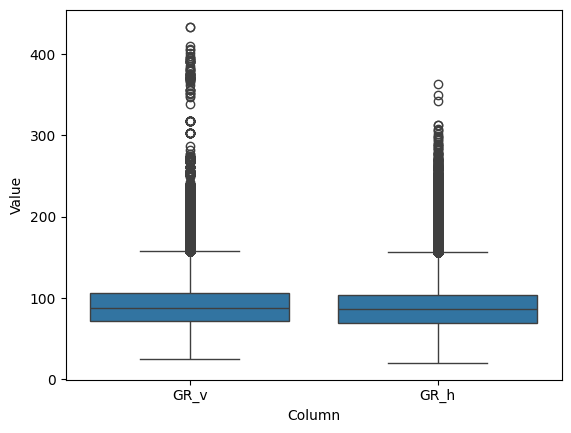

In [9]:
grs = train_df[['GR_v', 'GR_h']].melt(var_name='Column', value_name='Value')
sns.boxplot(grs, x='Column', y = 'Value')

In [10]:
train_df[['X', 'Y', 'Z']].describe()

,X,Y,Z
count,1308266.00,1308266.00,1308266.00
mean,2967537.83,1075336.05,-9283.63
std,46738.40,35326.51,654.97
min,2858892.37,1007175.50,-10841.23
25%,2921677.28,1041347.90,-9797.05
50%,2986783.91,1082701.82,-9164.50
75%,3007407.38,1104753.30,-8809.02
max,3037463.83,1138105.78,-7174.22


In [11]:
test_df.columns

Index(['id', 'MD', 'X', 'Y', 'Z', 'GR_h', 'TVT_input', 'TVT_v', 'GR_v'], dtype='object')

In [12]:
train_df.columns

Index(['id', 'MD', 'X', 'Y', 'Z', 'ANCC', 'ASTNU', 'ASTNL', 'EGFDU', 'EGFDL',
       'BUDA', 'TVT', 'GR_h', 'TVT_input', 'TVT_v', 'GR_v', 'Geology'],
      dtype='object')

# data processing

In [13]:
def data_processing(df): 
    df = df.sort_values(by = ['id', 'MD'])
    df = df.drop(['TVT_input', 'TVT_v'], axis = 1)
    if 'ANCC' in df.columns: 
        df = df.drop(['ANCC', 'ASTNU', 'ASTNL', 'EGFDU', 'EGFDL','BUDA','Geology'], axis = 1)
    # get angle of that well for different MD
    window = 3
    df[['dMD', 'dZ']] = df.groupby('id')[['MD', 'Z']].diff(periods=window)
    df['theta'] = (df['dZ']/df['dMD']).abs()
    df['theta'] = df['theta'].ffill().bfill()
    df[['dMD', 'dZ']] =  df[['dMD', 'dZ']].bfill()
    df = df.drop(['dMD'], axis = 1)
    df['relative_MD'] = df.groupby('id')['MD'].transform(lambda x: (x - x.min())/(x.max()-x.min()))
    df['GR_v_rmean'] =  df.groupby('id')['GR_v'].rolling(window=3, min_periods=1).mean().reset_index(level=0, drop=True)
    df['GR_v_rstd'] =  df.groupby('id')['GR_v'].rolling(window=3, min_periods=1).std().reset_index(level=0, drop=True)
    df['GR_h_rmean'] =  df.groupby('id')['GR_h'].rolling(window=3, min_periods=1).mean().reset_index(level=0, drop=True)
    df['GR_h_rstd'] =  df.groupby('id')['GR_h'].rolling(window=3, min_periods=1).std().reset_index(level=0, drop=True)
    df['GR_h'] = df['GR_h'].fillna(-999)
    df['X_rmean'] = df.groupby('id')['X'].rolling(window=3, min_periods=1).std().reset_index(level=0, drop=True)
    df['Y_rmean'] = df.groupby('id')['Y'].rolling(window=3, min_periods=1).std().reset_index(level=0, drop=True)
    df[['GR_v_rmean', 'GR_v_rstd', 'GR_h_rmean', 'GR_h_rstd', 'GR_h', 'X_rmean', 'Y_rmean']] =  df[['GR_v_rmean', 'GR_v_rstd', 'GR_h_rmean', 'GR_h_rstd', 'GR_h', 'X_rmean', 'Y_rmean']].bfill()

    rScaler = RobustScaler()
    mScaler = MinMaxScaler(feature_range=(0, 1))
    num_cols = df.select_dtypes(include='number').columns.tolist()
    
    if 'TVT' in num_cols: num_cols.remove('TVT')
    num_cols.remove('MD')
    num_cols.remove('relative_MD')
    df[num_cols] = rScaler.fit_transform(df[num_cols])
    df[num_cols] = mScaler.fit_transform(df[num_cols])

    ids =df['id'].unique()
    id_dict = dict(zip(ids, range(len(ids))))
    df['id'] = df['id'].map(id_dict)
    return df

In [14]:
train_df_p = data_processing(train_df.copy())
test_df_p = data_processing(test_df.copy())

In [15]:
train_df_p.isnull().sum()

id             0
MD             0
X              0
Y              0
Z              0
TVT            0
GR_h           0
GR_v           0
dZ             0
theta          0
relative_MD    0
GR_v_rmean     0
GR_v_rstd      0
GR_h_rmean     0
GR_h_rstd      0
X_rmean        0
Y_rmean        0
dtype: int64

<Axes: >

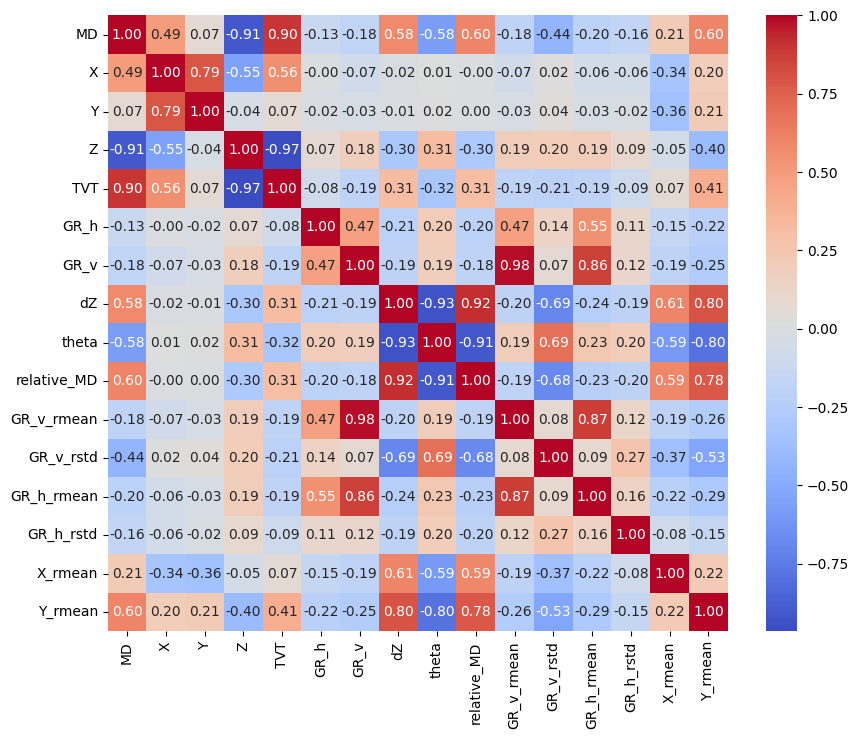

In [16]:
corr_mat = train_df_p.drop('id', axis = 1).corr(method = 'spearman')
plt.figure(figsize = (10,8))
sns.heatmap(corr_mat, cmap = 'coolwarm', annot=True, fmt = '.2f')

# Baseline 
## XGBoost
(note: this task is sequential, so xgboost isn't a good fit, but im just testing the most astray model)

In [17]:
xgb = XGBRegressor()
y = train_df_p.pop('TVT')

groups = train_df_p['id']
cv = GroupKFold()
scores = cross_val_score(xgb, train_df_p.drop('MD', axis=1), y, cv = cv, groups = groups,  scoring = 'neg_root_mean_squared_error')
scores = -scores
print(scores)
print(sum(scores)/len(scores))

[132.12196616  96.96042384 108.49665641 115.51319826 106.73911657]
111.96627224893487


## One Layer GRU

In [18]:
train_df_p

,id,MD,X,Y,Z,GR_h,GR_v,dZ,theta,relative_MD,GR_v_rmean,GR_v_rstd,GR_h_rmean,GR_h_rstd,X_rmean,Y_rmean
17159,0,11467.00,0.70,0.47,0.43,0.82,0.21,0.02,0.98,0.00,0.21,0.01,0.27,0.00,0.01,0.15
17160,0,11468.00,0.70,0.47,0.43,0.82,0.20,0.02,0.98,0.00,0.21,0.01,0.27,0.00,0.01,0.15
17161,0,11469.00,0.70,0.47,0.43,0.83,0.22,0.02,0.98,0.00,0.21,0.02,0.29,0.09,0.02,0.22
17162,0,11470.00,0.70,0.47,0.43,0.84,0.25,0.02,0.98,0.00,0.23,0.05,0.32,0.10,0.02,0.22
17163,0,11471.00,0.70,0.47,0.43,0.82,0.25,0.02,0.97,0.00,0.25,0.03,0.31,0.12,0.03,0.22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
404443,772,13805.00,0.48,0.05,0.02,0.77,0.08,0.81,0.05,1.00,0.08,0.00,0.09,0.01,0.25,0.96
404444,772,13806.00,0.48,0.05,0.02,0.78,0.08,0.81,0.05,1.00,0.08,0.00,0.09,0.02,0.25,0.96
404445,772,13807.00,0.48,0.05,0.02,0.78,0.08,0.81,0.05,1.00,0.08,0.00,0.10,0.01,0.25,0.97
404446,772,13808.00,0.48,0.05,0.02,0.00,0.08,0.81,0.05,1.00,0.08,0.00,0.10,0.00,0.25,0.96


In [19]:
q75_mu = train_df_p['id'].quantile(0.75)

In [20]:
def create_manual_windows(df, y_series, id_list, timesteps):
    X_windows = []
    y_targets = []
    # 1. Loop through each unique object to keep timelines completely isolated
    for obj_id in id_list:
        obj_mask = df['id'] == obj_id
        
        # 2. Extract and drop metadata features
        obj_features = df[obj_mask].drop(columns=['id','MD']).values
        obj_targets = y_series[obj_mask].values
        
        # 3. Create windows safely within this single object's timeline
        for i in range(len(obj_features) - timesteps):
            X_windows.append(obj_features[i : i + timesteps])
            
            # CRITICAL FIX: Extract only the single target value right AFTER the window
            y_targets.append(obj_targets[i + timesteps])
            
    return np.array(X_windows), np.array(y_targets)

In [21]:
train_df_p.groupby('id').size().describe()

count    773.00
mean    1692.45
std      217.34
min      851.00
25%     1546.00
50%     1703.00
75%     1839.00
max     2392.00
dtype: float64

In [22]:
strategy = tf.distribute.MirroredStrategy()
print(f"Number of devices being used for parallel processing: {strategy.num_replicas_in_sync}")

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Number of devices being used for parallel processing: 2


I0000 00:00:1781423752.274228      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781423752.279999      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [23]:
np.random.seed(42)
id_train = np.random.choice(train_df_p['id'].unique(), 300)

In [24]:
timestep = 50
train_idx = train_df_p.loc[train_df_p.id.isin(id_train)].index
val_idx = train_df_p.loc[~train_df_p.id.isin(id_train)].index
X_train, X_val = train_df_p.loc[train_idx], train_df_p.loc[val_idx]
y_train, y_val = y[train_idx], y[val_idx]
X_train, y_train = create_manual_windows(X_train, y_train, X_train.id.unique(), timestep)
X_val, y_val = create_manual_windows(X_val, y_val, X_val.id.unique(), timestep)

In [25]:
X_diff = np.diff(X_train[42], axis = 0, prepend=[X_train[42][0]])
X_train_te = np.expand_dims(X_diff, axis=0)
keras.utils.set_random_seed(42)

model = Sequential(
    [
        Input(shape=(timestep, X_train.shape[2])),
        Conv1D(64, kernel_size=3, padding='same', activation='relu', name ='cnn256'),
        GRU(64, return_sequences = True, name = 'gru1'),
        GRU(32, return_sequences = True, name = 'gru2'),
        Bidirectional(GRU(16, return_sequences=False, 
                kernel_regularizer=regularizers.l1_l2(l1 = 1e-5, l2 = 1e-4), 
                name = 'gru')),
        Dense(32, activation='relu'),
        Dropout(5e-3),
        Dense(1, activation='linear')
    ]
)

#cnn256 = model.get_layer('cnn256').output
#cnn128 = model.get_layer('cnn128').output
#gru1 = model.get_layer('gru1').output
gru1 = model.get_layer('gru1').output
#cnn32 = model.get_layer('cnn32').output
gru2 = model.get_layer('gru2').output

#intermediate_model1 =  Model(inputs = model.layers[0].input, outputs = cnn256)
#intermediate_model2 =  Model(inputs = model.layers[0].input, outputs = cnn128)
#intermediate_model3 =  Model(inputs = model.layers[0].input, outputs = gru1)
intermediate_model4 =  Model(inputs = model.layers[0].input, outputs = gru1)
#intermediate_model5 =  Model(inputs = model.layers[0].input, outputs = cnn32)
intermediate_model6 =  Model(inputs = model.layers[0].input, outputs = gru2)

#features_256 = intermediate_model1.predict(X_train_te)
#features_128 = intermediate_model2.predict(X_train_te)
#features_gru1= intermediate_model3.predict(X_train_te)
features_gru1 = intermediate_model4.predict(X_train_te)
#features_32 = intermediate_model5.predict(X_train_te)
features_gru2 = intermediate_model6.predict(X_train_te)

I0000 00:00:1781423760.737241      76 cuda_dnn.cc:529] Loaded cuDNN version 91002


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step


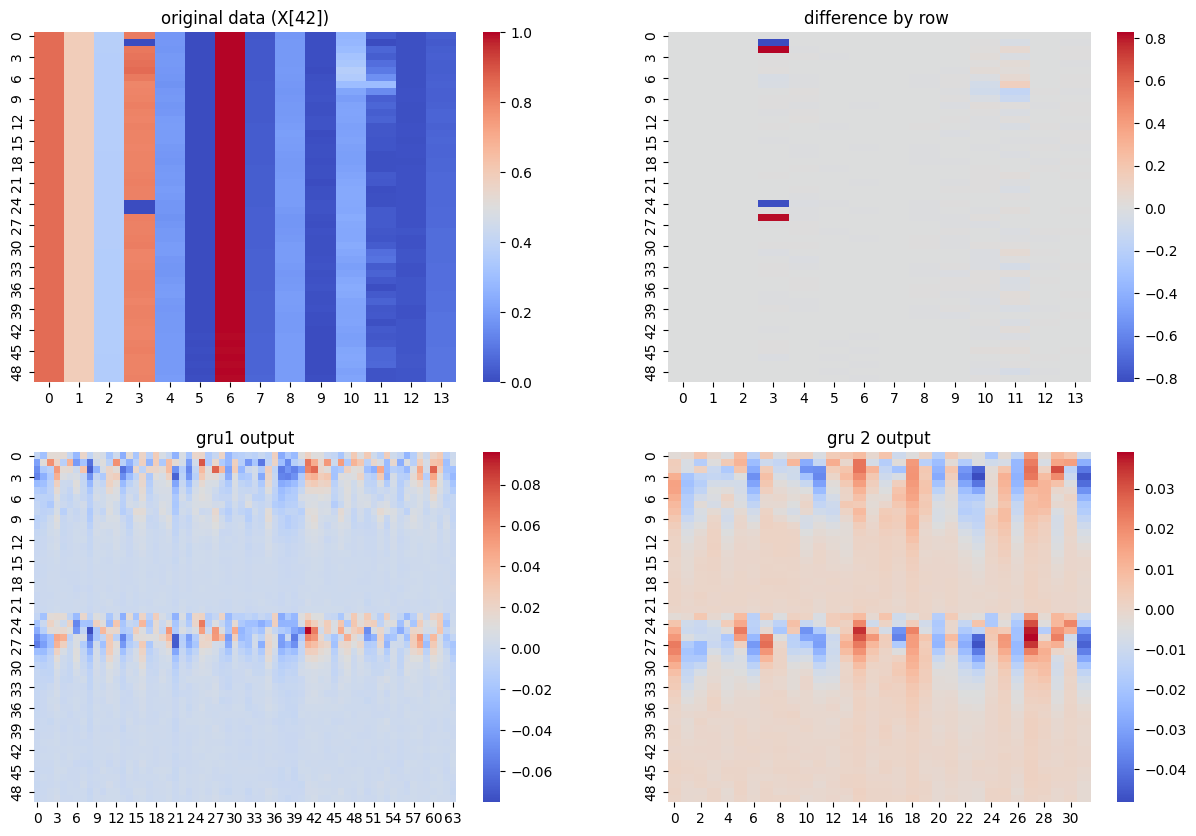

In [26]:
fig, ax = plt.subplots(2, 2, figsize = (15, 10))
sns.heatmap(X_train[42], cmap = 'coolwarm', ax = ax[0][0])
sns.heatmap(X_diff, cmap = 'coolwarm', ax = ax[0][1])
#sns.heatmap(features_256[0], cmap = 'coolwarm', ax = ax[0][2])
#sns.heatmap(features_128[0], cmap = 'coolwarm', ax = ax[0][3])
#sns.heatmap(features_gru1[0], cmap = 'coolwarm', ax = ax[1][0])
sns.heatmap(features_gru1[0], cmap = 'coolwarm', ax = ax[1][0])
#sns.heatmap(features_32[0], cmap = 'coolwarm', ax = ax[1][2])
sns.heatmap(features_gru2[0], cmap = 'coolwarm', ax = ax[1][1])

#ax[0][3].set_axis_off()
#ax[0][2].set_axis_off()
#ax[1][0].set_axis_off()
#x[1][2].set_axis_off()
#sns.heatmap(features256[0], cmap = 'coolwarm', ax = ax[1][2])
#sns.heatmap(features_mp2[0], cmap = 'coolwarm', ax = ax[1][3])
_ = ax[0][0].set_title('original data (X[42])')
_ = ax[0][1].set_title('difference by row ')
#_ = ax[0][2].set_title('cnn 256 layer output')
#_ = ax[0][3].set_title('cnn 128 layer output')
#_ = ax[1][0].set_title('gru 1 output')
_ = ax[1][0].set_title('gru1 output')
#_ = ax[1][2].set_title('cnn 32 layer output')
_ = ax[1][1].set_title('gru 2 output')

In [27]:
gkf = GroupKFold(n_splits=2, shuffle=True, random_state=42)
scores = []

output_dir = '/kaggle/working/model_logs'
os.makedirs(output_dir, exist_ok=True)

timestep = 50
i = 0
for fold, (train_idx, val_idx) in enumerate(gkf.split(train_df_p, y, groups=groups)):
    X_train, X_val = train_df_p.loc[train_idx], train_df_p.loc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    X_train, y_train = create_manual_windows(X_train, y_train, X_train.id.unique(), timestep)
    X_val, y_val = create_manual_windows(X_val, y_val, X_val.id.unique(), timestep)

    X_train = np.diff(X_train, axis=1, prepend=X_train[:, :1, :])
    X_val = np.diff(X_val, axis=1, prepend=X_val[:, :1, :])
    #y_train = y_train[1:]
    #y_val = y_val[1:]
    
    keras.utils.set_random_seed(42)
    with strategy.scope():
        model = Sequential(
            [
                Input(shape=(timestep, X_train.shape[2])),
                Conv1D(128, kernel_size=3, padding='same', name ='cnn128'),
                BatchNormalization(name='bn_cnn128'),
                Activation('relu', name='relu_cnn128'),
                Conv1D(64, kernel_size=3, padding='same', name ='cnn64'),
                BatchNormalization(name='bn_cnn64'),
                Activation('relu', name='relu_cnn64'),
                Conv1D(32, kernel_size=3, padding='same', name ='cnn32'),
                BatchNormalization(name='bn_cnn32'),
                Activation('relu', name='relu_cnn32'),
                Bidirectional(GRU(32, return_sequences=False, 
                        kernel_regularizer=regularizers.l1_l2(l1 = 1e-5, l2 = 1e-4), 
                        name = 'gru')),
                Dense(32, activation='relu'),
                Dropout(0.3),
                Dense(1, activation='linear')
            ]
        )
        model.compile(optimizer='adam', loss='mean_squared_error')
        model.optimizer.learning_rate.assign(1e-4)

    csv_logger = tf.keras.callbacks.CSVLogger(
        filename=os.path.join(output_dir, f'epoch_logs{i}.csv'),
        append=True, # Appends info if you resume training
        separator=','
    )

    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',     
        patience=3,          
        restore_best_weights=True 
    )
    
    history = model.fit(X_train, 
          y_train,  
          validation_data=(X_val, y_val),
          epochs=50, 
          verbose=1,  
          callbacks=[early_stopping, csv_logger],
          shuffle = True)
    loss = min(history.history['val_loss'])
    scores.append(np.sqrt(loss))
    print(np.sqrt(loss))
    i+=1

print(f"\nAverage Cross-Validation RMSE across all groups: {np.mean(scores):.4f}")


INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
Epoch 1/50
INFO:tensorflow:Collective all_reduce tensors: 22 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1


I0000 00:00:1781423786.925735      75 cuda_dnn.cc:529] Loaded cuDNN version 91002


19487/19487 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 114945512.0000INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
19487/19487 ━━━━━━━━━━━━━━━━━━━━ 458s 23ms/step - loss: 114944344.0000 - val_loss: 37802824.